In [1]:
import glob
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import rioxarray as rio
from geocube.api.core import make_geocube
from IPython.display import Image
from matplotlib.colors import ListedColormap

# Calculate reach characteristics

Mathias has digitised riparian vegetation and decided on a "base level" for each study area (i.e. a elevation from which vegetation heights can be estimated). This notebook performs data analysis for each site. See e-mail from Mathias received 02.03.2025 for details.

The main input datasets are:

 * **NDVI** and **surface elevation** grids created by NodeODM and processed in notebook 01. DSMs have been resampled to match the extent and resolution of the NDVI grids.
   
 * **Stream centre-lines** digitised by Mathias.
   
 * **Riparian zone polygons** defining areas of interest on the left and right banks of each stream. These were created from the stream centre-lines using rules provided by Mathias. See the notebook [here](https://nbviewer.org/github/NIVANorge/riparian_zone_remote_sensing/blob/main/notebooks/create_buffers.ipynb) for details.

 * **Riparian vegetation polygons** manually digitised by Mathias defining patches of coherent riparian vegetation.

## 1. Datasets to process

In [2]:
# Read list of datasets to process
ds_list_xlsx = r"../data/halden_baselevels_and_paths.xlsx"
df = pd.read_excel(ds_list_xlsx)
df = df.query("to_be_analysed == 'y'").reset_index(drop=True)
df.head()

,site,base_line_height,base_height_coordinates,stream_id,stream_width,to_be_analysed,dsm,ndvi
0,H20 L,192.066299,"11°26'1,229""E 59°56'26,902""N",H20a,1.5,y,niva-tidy/2023/niva_202308301149_halden_h20_rg...,niva-tidy/2023/niva_202308301136_halden_h20_ms...
1,H20 R,192.705368,"11°26'1,808""E 59°56'26,932""N",H20b,1.5,y,niva-tidy/2023/niva_202308301149_halden_h20_rg...,niva-tidy/2023/niva_202308301136_halden_h20_ms...
2,H21 L,192.179993,"11°26'52,241""E 59°56'27,869""N",H21a,2.5,y,niva-tidy/2023/niva_202308301109_halden_h21_rg...,niva-tidy/2023/niva_202308301118_halden_h21_ms...
3,H21 R,192.670471,"11°26'53,417""E 59°56'27,724""N",H21b,2.5,y,niva-tidy/2023/niva_202308301109_halden_h21_rg...,niva-tidy/2023/niva_202308301118_halden_h21_ms...
4,H22 L,161.835281,"11°34'44,749""E 59°53'1,058""N",H22a,2.5,y,niva-tidy/2023/niva_202308300741_halden_h22_rg...,niva-tidy/2023/niva_202308300752_halden_h22_ms...


## 2. Read vector data

In [3]:
# Paths to shapefiles from Mathias
str_shp_path = r"../gis/shapefiles/Streams.shp"
rip_shp_path = r"../gis/shapefiles/Riparian_buffers.shp"
veg_shp_path = r"../gis/shapefiles/Riparian_veg_width.shp"

# Read geodataframes
str_gdf = gpd.read_file(str_shp_path)
rip_gdf = gpd.read_file(rip_shp_path)
veg_gdf = gpd.read_file(veg_shp_path)

## 3. Reach characteristics

The metrics of interest are described in the Word document sent by Mathias on 02.03.2025.

In [4]:
# Dict to store results
res_dict = dict()

### 3.1. Shading

The stream area is defined by "buffering" the stream centre-line based on stream widths measured in the field. This area is split into left and right stream banks using the riparian zone polygons, and the percentage of shading on each side of the stream is determined as the ratio of pixels with NDVI greater than a **threshold of 0.2**:

 * Area of stream shaded: NDVI ≥ 0.2
 * Area of open stream: NDVI < 0.2

,site,stream_area_m2,shading_pct
0,H20 L,37.5,100.0
1,H20 R,37.5,100.0
2,H21 L,62.4,99.2
3,H21 R,62.6,99.3
4,H22 L,63.2,44.8
5,H22 R,63.1,42.1
6,H23 R,227.7,36.0
7,H24 L,50.3,64.2
8,H24 R,50.3,31.9
9,H25 L,58.3,19.9


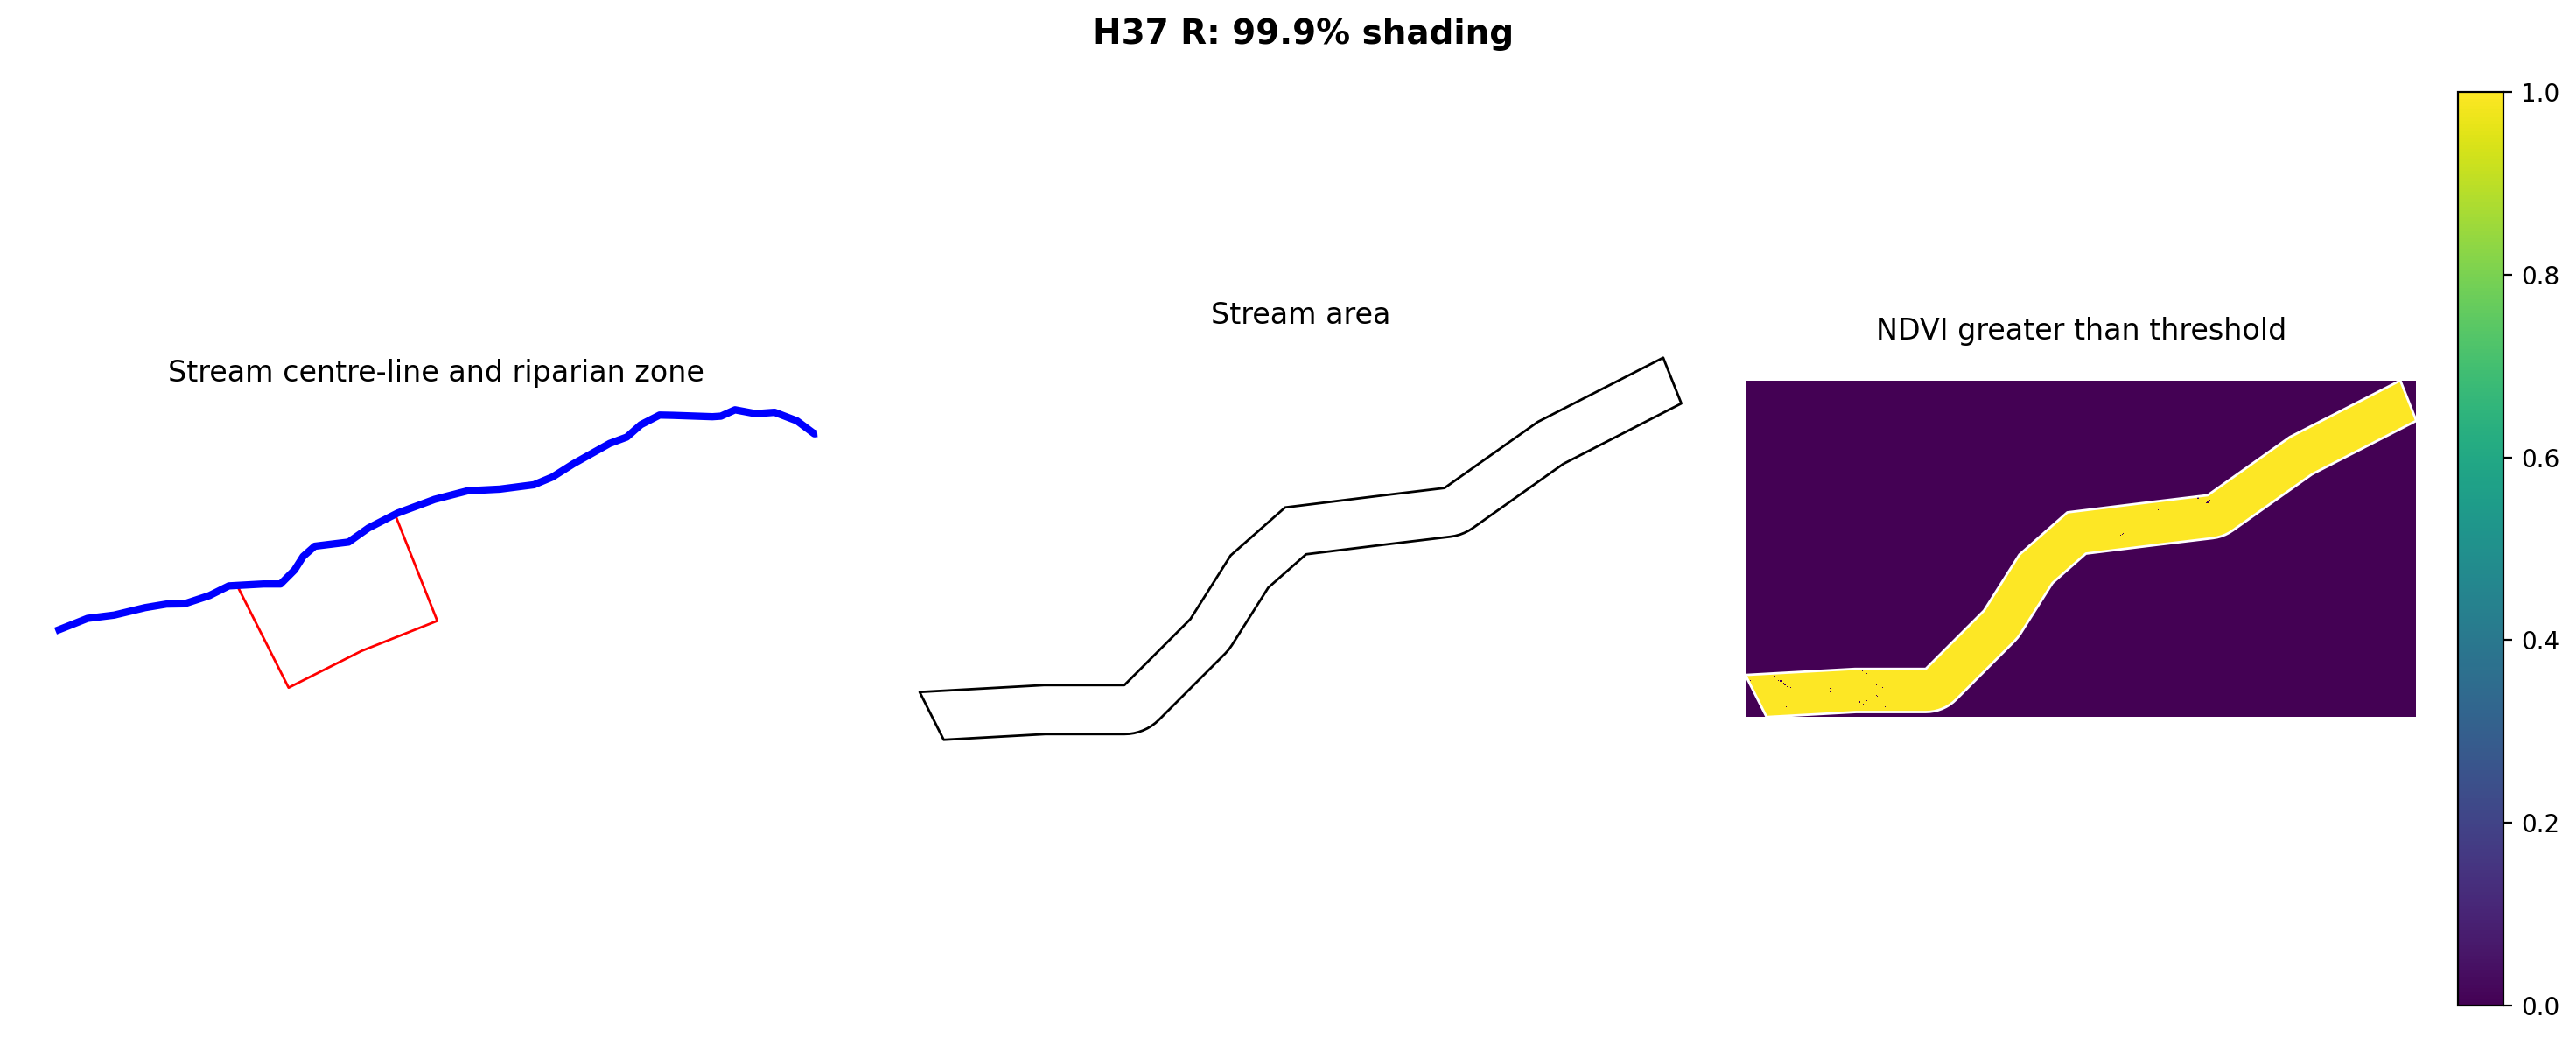

In [5]:
# Pixels within the buffer with values < 'ndvi_thresh' are considered to be unshaded;
# pixels with values >= 'ndvi_thresh' are considered shaded.
ndvi_thresh = 0.2

# Loop over datasets
shade_dict = {
    "site": [],
    "stream_area_m2": [],
    "shading_pct": [],
}
for idx, row in df.iterrows():
    width = row["stream_width"]
    str_id = row["stream_id"]
    site = row["site"]
    site_main = site[:3]

    # Setup plot
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

    # Get vector data for site
    site_str_gdf = str_gdf.query("Stream_id == @site_main").copy()
    site_rip_gdf = rip_gdf.query("Stream_id == @str_id").copy()

    # Plot "raw" stream line and riparian zone
    site_rip_gdf.plot(ax=axes[0], facecolor="none", edgecolor="r", lw=1)
    site_str_gdf.plot(ax=axes[0], edgecolor="b", lw=3)
    axes[0].set_title("Stream centre-line and riparian zone")
    axes[0].axis("off")

    # Buffer the stream
    site_str_gdf["geometry"] = site_str_gdf.buffer(width / 2)

    # Clip stream to riparian poly
    site_str_gdf = gpd.clip(site_str_gdf, site_rip_gdf, keep_geom_type=True)

    # Plot buffered stream, clipped to riparian zone
    site_str_gdf.plot(ax=axes[1], edgecolor="k", facecolor="none", lw=1)
    axes[1].set_title("Stream area")
    axes[1].axis("off")

    # Read NDVI data
    ndvi_tif_path = os.path.join("/home/notebook/shared-seabee-ns9879k", row["ndvi"])
    ndvi_data = rio.open_rasterio(ndvi_tif_path, mask_and_scale=True)

    # Reproject if necessary
    site_str_gdf = site_str_gdf.to_crs(ndvi_data.rio.crs)

    # Extract pixels within buffer
    masked_ndvi = ndvi_data.rio.clip(site_str_gdf.geometry, site_str_gdf.crs)

    # Calculate the proportion of pixels with values >= ndvi_thresh
    buffer_pixels = masked_ndvi.notnull().sum().item()
    shaded_pixels = (masked_ndvi >= ndvi_thresh).sum().item()
    shade_pct = 100 * shaded_pixels / buffer_pixels

    # Plot NDVI above threshold
    (masked_ndvi >= ndvi_thresh).plot(ax=axes[2])
    site_str_gdf.plot(ax=axes[2], edgecolor="white", facecolor="none", lw=1)
    axes[2].set_title("NDVI greater than threshold")
    axes[2].axis("off")
    fig.suptitle(f"{site}: {shade_pct:.1f}% shading", fontsize=14, fontweight="bold")
    plt.tight_layout()

    # Save plot
    png_path = f"../plots/shading/shading_{site.replace(' ', '-').lower()}.png"
    plt.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.close()

    # Results to dict
    shade_dict["site"].append(site)
    shade_dict["stream_area_m2"].append(site_str_gdf.geometry.area.item())
    shade_dict["shading_pct"].append(shade_pct)

# Build results dataframe
shade_df = pd.DataFrame(shade_dict)
shade_df["shading_pct"] = shade_df["shading_pct"].round(1)
shade_df["stream_area_m2"] = shade_df["stream_area_m2"].round(1)
res_dict["shading"] = shade_df

# Show results
display(shade_df)
Image(filename=png_path)

### 3.2. Width of riparian vegetation

Mathias has drawn polygons delineating the extent of riparian vegetation. These polygons are processed as follows:

 1. Clip to remove the stream area (estimated by buffering the stream centre lines, as above).
    
 2. Clip using the riparian extent polygons, which define areas of interest on the left and right banks of the stream. For each bank, this yields a set of polygons of arbitrary shape.
    
We want to estimate the mean "width" of these polygons. However, "width" is not clearly defined for arbitrary shapes. A computationally efficient solution is to model each polygon as a rectangle with the same perimeter and area as the original shape. For a rectangle of width, $w$, and length, $l$:

$$A = w \times l$$ 

and 

$$P = 2w + 2l$$

rewriting the first equation as $l = \frac{A}{w}$ and substituting it into the second gives

$$P = 2w + \frac{2A}{w}$$

or

$$2w^2 - Pw + 2A = 0$$

This quadratic equation has two solutions, where the smallest is the width and the largest is the length:

$$w = \frac{P - \sqrt{P^2 - 16A}}{4}$$

$$l = \frac{P + \sqrt{P^2 - 16A}}{4}$$

These equations can be used to estimate the length and width of any reasonably elongated arbitrary polygon.

,site,mean_width_m
0,H20 L,3.1
1,H20 R,7.9
2,H21 L,11.7
3,H21 R,19.3
4,H22 L,4.6
5,H22 R,2.2
6,H23 R,29.5
7,H24 L,8.0
8,H24 R,2.3
9,H25 L,22.9


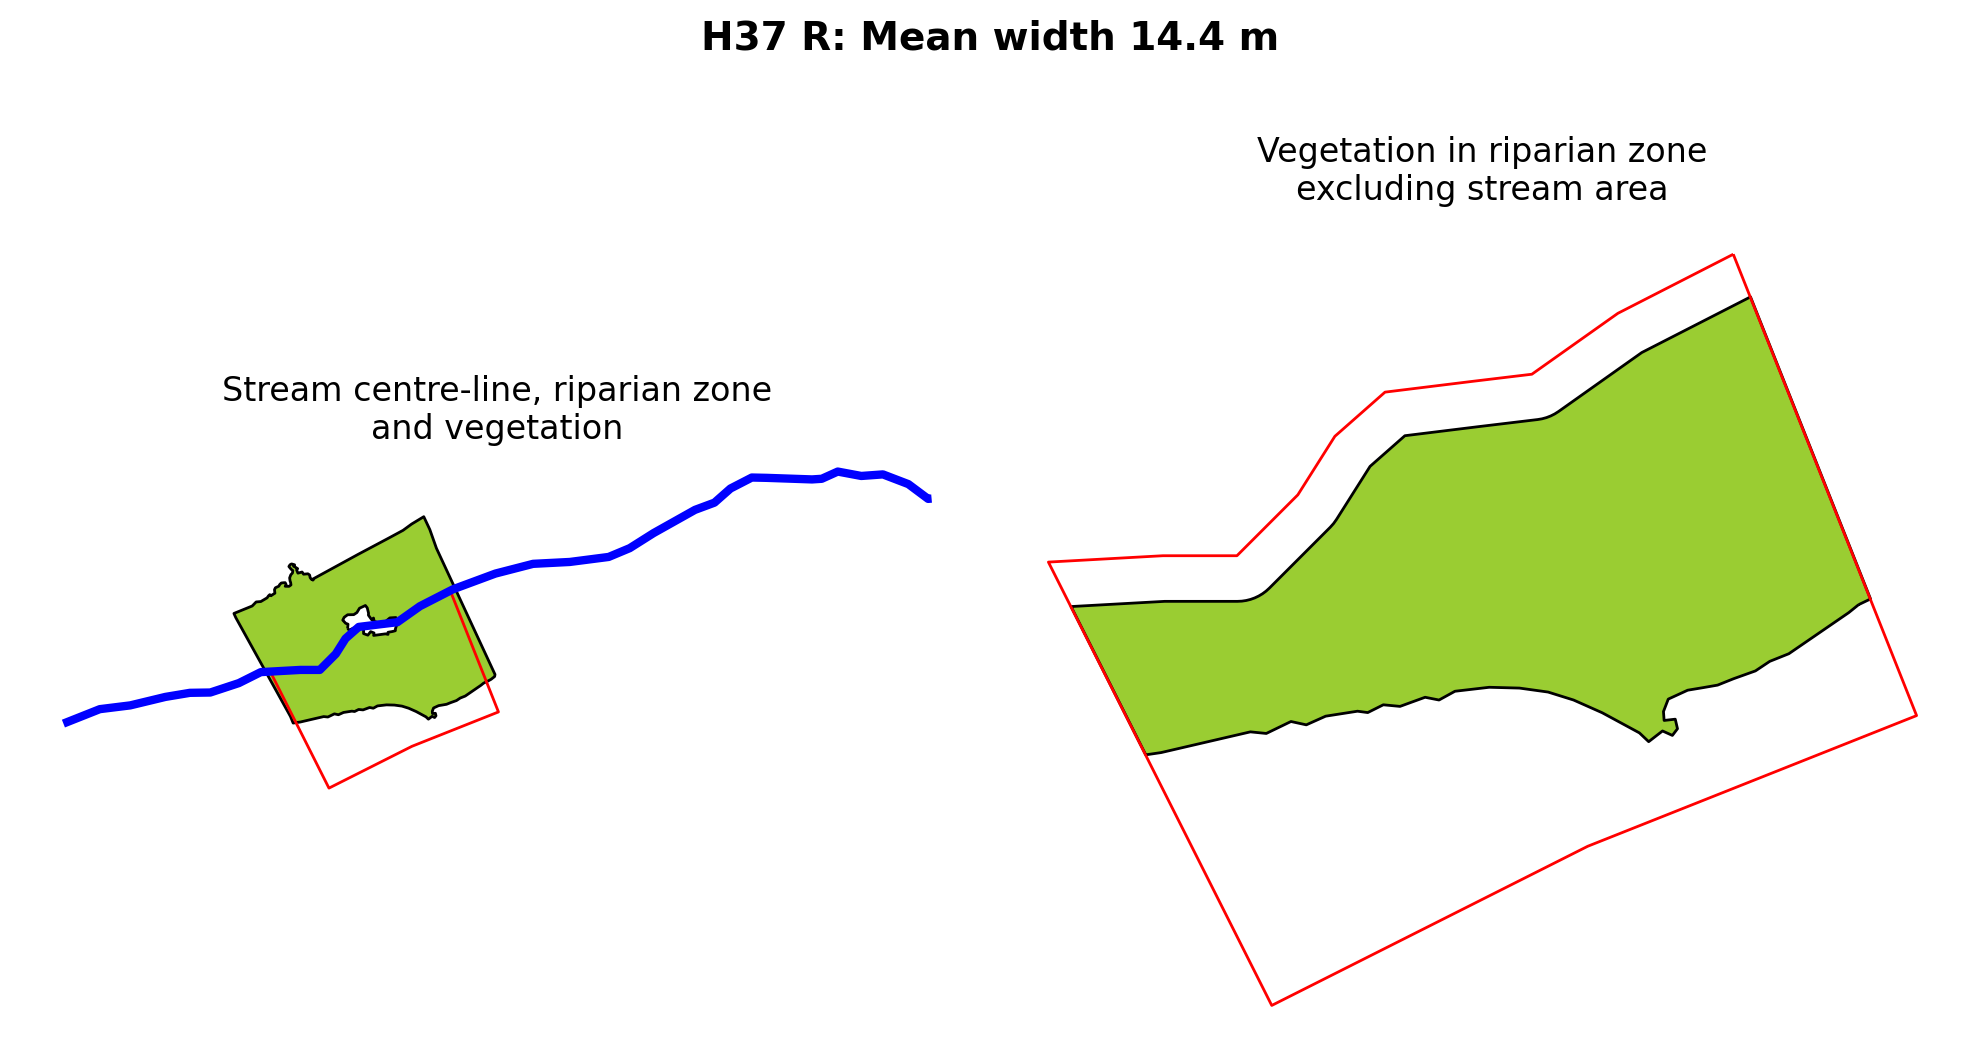

In [6]:
# Loop over datasets
width_dict = {
    "site": [],
    "mean_width_m": [],
}
for idx, row in df.iterrows():
    width = row["stream_width"]
    str_id = row["stream_id"]
    site = row["site"]
    site_main = site[:3]

    # Setup plot
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

    # Get vector data for site
    site_str_gdf = str_gdf.query("Stream_id == @site_main").copy()
    site_rip_gdf = rip_gdf.query("Stream_id == @str_id").copy()
    site_veg_gdf = veg_gdf.query("Stream_ID == @site_main").copy()

    # Plot "raw" stream line, riparian zone, and vegetation
    site_veg_gdf.plot(ax=axes[0], edgecolor="k", facecolor="yellowgreen", lw=1)
    site_str_gdf.plot(ax=axes[0], edgecolor="b", lw=3)
    site_rip_gdf.plot(ax=axes[0], facecolor="none", edgecolor="r", lw=1)
    axes[0].set_title("Stream centre-line, riparian zone\nand vegetation")
    axes[0].axis("off")

    # Buffer streams
    site_str_gdf["geometry"] = site_str_gdf.buffer(width / 2)

    # Clip vegetation with stream poly
    site_veg_gdf = site_veg_gdf.overlay(site_str_gdf, how="difference")

    # Clip vegetation with riparian poly
    site_veg_gdf = gpd.clip(site_veg_gdf, site_rip_gdf, keep_geom_type=True)

    # Plot the clipped vegetation
    site_veg_gdf.plot(ax=axes[1], edgecolor="k", facecolor="yellowgreen", lw=1)
    site_rip_gdf.plot(ax=axes[1], facecolor="none", edgecolor="r", lw=1)
    axes[1].set_title("Vegetation in riparian zone\nexcluding stream area")
    axes[1].axis("off")

    # Check CRS OK for area and perim calculations
    assert "UTM" in site_veg_gdf.crs.name

    # Calculate perimeter and area
    site_veg_gdf["perim_m"] = site_veg_gdf.geometry.length
    site_veg_gdf["area_m2"] = site_veg_gdf.geometry.area

    # Estimate width and length for each vegetation patch
    site_veg_gdf["width_m"] = (
        site_veg_gdf["perim_m"]
        - (site_veg_gdf["perim_m"] ** 2 - 16 * site_veg_gdf["area_m2"]) ** 0.5
    ) / 4

    # Calculate mean width and length for site
    mean_width = site_veg_gdf["width_m"].mean()

    # Save plot
    fig.suptitle(
        f"{site}: Mean width {mean_width:.1f} m", fontsize=14, fontweight="bold"
    )
    plt.tight_layout()
    png_path = (
        f"../plots/vegetation_width/veg_width_{site.replace(' ', '-').lower()}.png"
    )
    plt.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.close()

    # Add to results
    width_dict["site"].append(site)
    width_dict["mean_width_m"].append(mean_width)

# Add to results
width_df = pd.DataFrame(width_dict)
width_df["mean_width_m"] = width_df["mean_width_m"].round(1)
res_dict["vegetation_width"] = width_df

# Show results
display(width_df)
Image(filename=png_path)

### 3.3. Buffer "intactness"

The stream centre-line is buffered by half the stream width to identify the river bank. A buffer of a further 2 m is then created representing the area within 2 m of the stream bank. This is then clipped by the riparian area polygons to split the bank area between left and right banks. For each bank area polygon, the proportion of cells where vegetation height is greater than or equal to 0.3 m and NDVI is greater than or equal to 0.2 is calculated.

,site,intact_pct
0,H20 L,91.3
1,H20 R,100.0
2,H21 L,99.6
3,H21 R,99.9
4,H22 L,97.1
5,H22 R,54.3
6,H23 R,92.1
7,H24 L,61.2
8,H24 R,40.8
9,H25 L,64.5


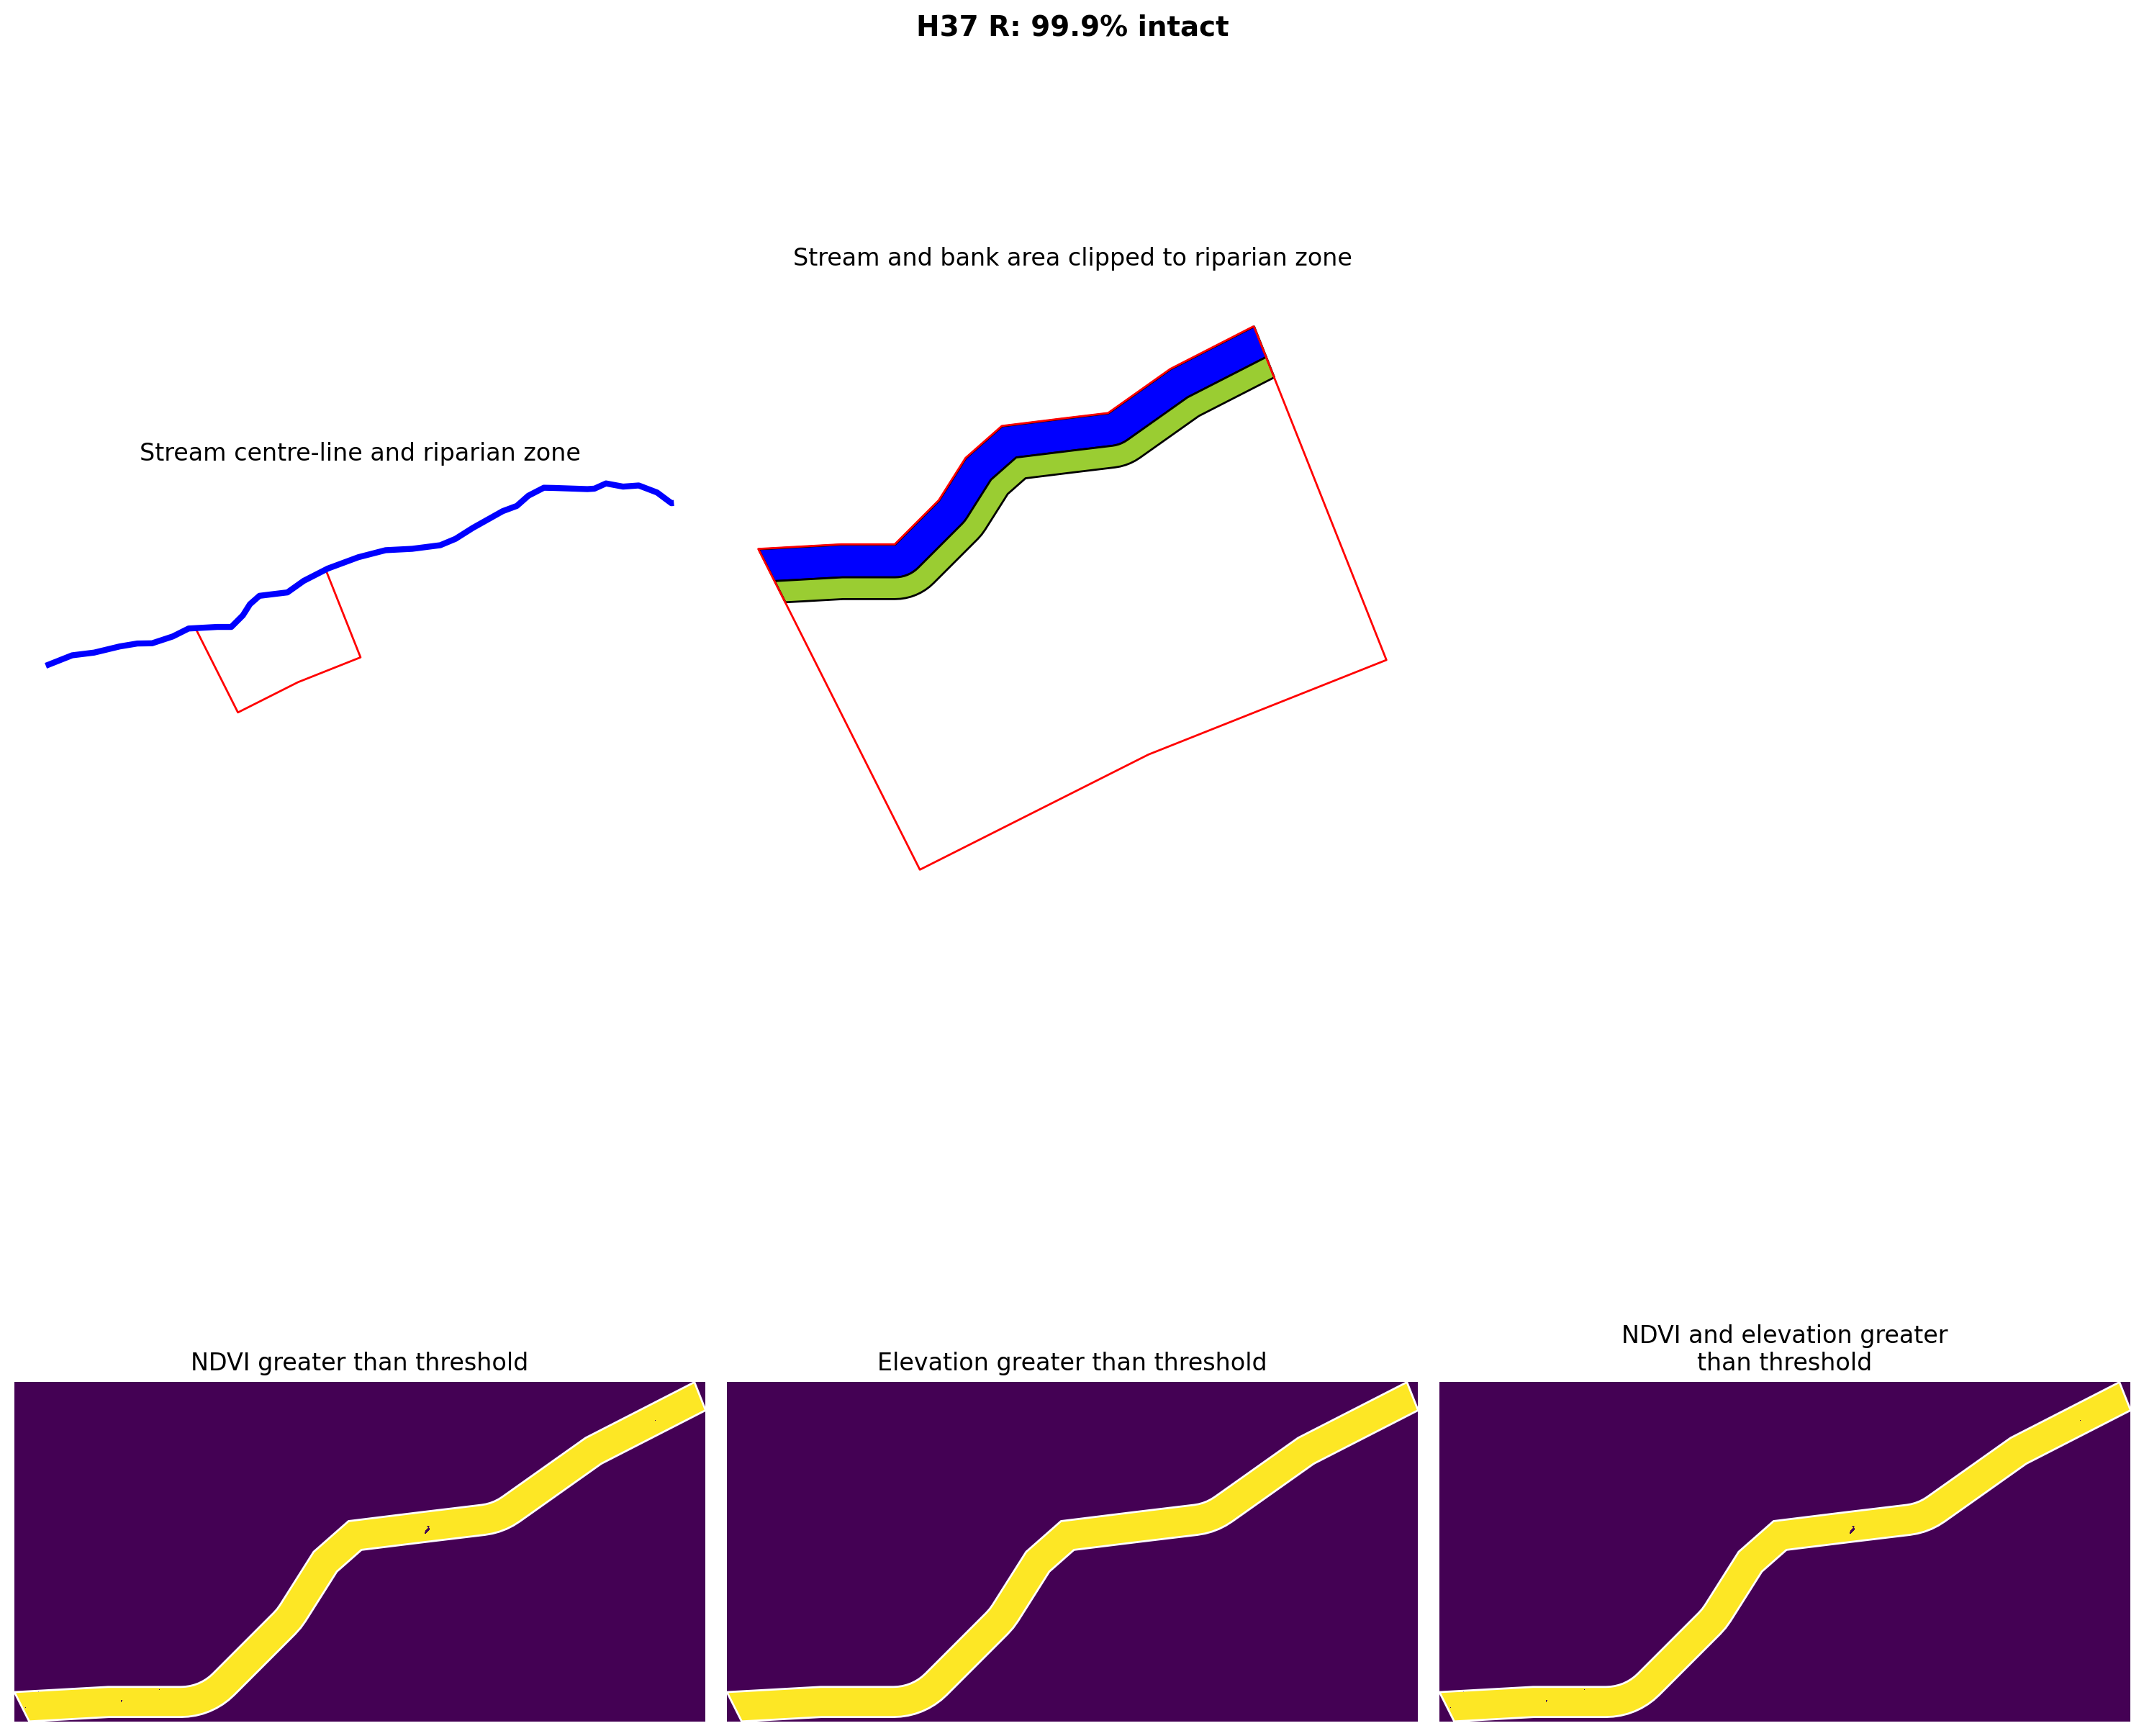

In [7]:
# A buffer is defined as being "intact" if NDVI >= ndvi_thresh AND
# vegetation height >= height_thresh
ndvi_thresh = 0.2
height_thresh = 0.3  # metres

# Loop over datasets
intact_dict = {
    "site": [],
    "intact_pct": [],
}
for idx, row in df.iterrows():
    base_elev = row["base_line_height"]
    width = row["stream_width"]
    str_id = row["stream_id"]
    site = row["site"]
    site_main = site[:3]

    # Setup plot
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 15))

    # Get vector data for site
    site_str_gdf = str_gdf.query("Stream_id == @site_main").copy()
    site_rip_gdf = rip_gdf.query("Stream_id == @str_id").copy()
    site_bank_gdf = str_gdf.query("Stream_id == @site_main").copy()

    # Plot "raw" stream line and riparian zone
    site_rip_gdf.plot(ax=axes[0, 0], facecolor="none", edgecolor="r", lw=1)
    site_str_gdf.plot(ax=axes[0, 0], edgecolor="b", lw=3)
    axes[0, 0].set_title("Stream centre-line and riparian zone")
    axes[0, 0].axis("off")

    # Buffer streams to stream bank
    site_str_gdf["geometry"] = site_str_gdf.buffer(width / 2)

    # Buffer streams to stream bank + 2 m
    site_bank_gdf["geometry"] = site_bank_gdf.buffer((width / 2) + 2)

    # Remove stream area from stream bank
    site_bank_gdf = site_bank_gdf.overlay(site_str_gdf, how="difference")

    # Clip stream area and bank with riparian poly
    site_bank_gdf = gpd.clip(site_bank_gdf, site_rip_gdf, keep_geom_type=True)
    site_str_gdf = gpd.clip(site_str_gdf, site_rip_gdf, keep_geom_type=True)

    # Plot stream and bank area, clipped to riparian zone
    site_str_gdf.plot(ax=axes[0, 1], edgecolor="k", facecolor="b", lw=1)
    site_bank_gdf.plot(ax=axes[0, 1], edgecolor="k", facecolor="yellowgreen", lw=1)
    site_rip_gdf.plot(ax=axes[0, 1], facecolor="none", edgecolor="r", lw=1)
    axes[0, 1].set_title("Stream and bank area clipped to riparian zone")
    axes[0, 1].axis("off")

    # Read NDVI data
    ndvi_tif_path = os.path.join("/home/notebook/shared-seabee-ns9879k", row["ndvi"])
    ndvi_data = rio.open_rasterio(ndvi_tif_path, mask_and_scale=True)

    # Read elevation data that was resampled to match NDVI in previous notebook
    mission_dir = row["ndvi"].split("/")[2]
    search_path = os.path.join(
        "/home/notebook/shared-seabee-ns9879k/niva-tidy/2023",
        mission_dir,
        "rgb_dsm_resampled",
        "*_dsm.tif",
    )
    flist = glob.glob(search_path)
    assert len(flist) == 1
    dem_tif_path = flist[0]
    dem_data = rio.open_rasterio(dem_tif_path, mask_and_scale=True)

    # Subtract baseline elevation to give vegetation height
    dem_data = dem_data - base_elev

    # Reproject if necessary
    assert ndvi_data.rio.crs == dem_data.rio.crs
    assert ndvi_data.shape == dem_data.shape
    site_bank_gdf = site_bank_gdf.to_crs(ndvi_data.rio.crs)

    # Extract pixels within bank area
    masked_ndvi = ndvi_data.rio.clip(site_bank_gdf.geometry, site_bank_gdf.crs)
    masked_dem = dem_data.rio.clip(site_bank_gdf.geometry, site_bank_gdf.crs)

    # Calculate the proportion of pixels meeting criteria
    not_nan = ~np.isnan(masked_ndvi.values) & ~np.isnan(masked_dem.values)
    intact = (masked_ndvi.values >= ndvi_thresh) & (masked_dem.values >= height_thresh)
    intact_pct = 100 * intact.sum() / not_nan.sum()

    # Build a dataset for the intact area
    intact_ds = masked_dem.copy()
    intact_ds.values = intact

    # Plot NDVI above threshold
    (masked_ndvi >= ndvi_thresh).plot(ax=axes[1, 0], add_colorbar=False)
    site_bank_gdf.plot(ax=axes[1, 0], edgecolor="white", facecolor="none", lw=1)
    axes[1, 0].set_title("NDVI greater than threshold")
    axes[1, 0].axis("off")

    # Plot DEM above threshold
    (masked_dem >= height_thresh).plot(ax=axes[1, 1], add_colorbar=False)
    site_bank_gdf.plot(ax=axes[1, 1], edgecolor="white", facecolor="none", lw=1)
    axes[1, 1].set_title("Elevation greater than threshold")
    axes[1, 1].axis("off")

    # Plot combination
    intact_ds.plot(ax=axes[1, 2], add_colorbar=False)
    site_bank_gdf.plot(ax=axes[1, 2], edgecolor="white", facecolor="none", lw=1)
    axes[1, 2].set_title("NDVI and elevation greater\nthan threshold")
    axes[1, 2].axis("off")
    fig.delaxes(axes[0, 2])
    fig.suptitle(f"{site}: {intact_pct:.1f}% intact", fontsize=14, fontweight="bold")
    plt.tight_layout()

    # Save plot
    png_path = f"../plots/intactness/intactness_{site.replace(' ', '-').lower()}.png"
    plt.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.close()

    # Add to results
    intact_dict["site"].append(site)
    intact_dict["intact_pct"].append(intact_pct)

# Add to results
intact_df = pd.DataFrame(intact_dict)
intact_df["intact_pct"] = intact_df["intact_pct"].round(1)
res_dict["intactness"] = intact_df

# Show results
display(intact_df)
Image(filename=png_path)

### 3.4. Vegetation composition

This analysis is repeated twice with two different areas of interest: (i) the entire riparian area, and (ii) the vegetation polygons only (see section 3.4.1 and 3.4.2, below).

For each site, we first identify vegetation within the area of interest, defined as cells where NDVI ≥ 0.2. We are interested in the height distribution of these cells, divided into five classes. A 6th class - class 0 - is added for cells where baseline-adjusted heights are less than zero. These can probably be ignored, but are included for completeness. The class boundaries are:

 * Class 0: < 0 m
 * Class 1: 0 – 0.3 m
 * Class 2: 0.3 – 2 m
 * Class 3: 2 – 5 m
 * Class 4: 5 – 1 2m
 * Class 5: >12 m

We want to know the total vegetation area and the proportion in each of the five classes.

#### 3.4.1. Whole riparian area

The areas of interest are the polygons defining the entire riparian area.

,site,veg_area_m2,class_0_pct,class_1_pct,class_2_pct,class_3_pct,class_4_pct,class_5_pct
0,H20 L,920.2,0.3,14.3,30.5,16.7,23.8,14.4
1,H20 R,1493.2,0.1,9.4,66.6,2.2,15.4,6.4
2,H21 L,1437.5,6.1,5.7,37.8,28.3,7.6,14.6
3,H21 R,1585.5,7.8,1.9,8.5,4.8,26.6,50.4
4,H22 L,939.6,0.0,0.6,38.4,51.3,9.6,0.0
5,H22 R,338.3,0.7,8.2,88.9,2.1,0.1,0.0
6,H23 R,1428.1,0.2,5.2,17.5,8.8,61.1,7.2
7,H24 L,1532.6,0.7,1.8,5.9,57.5,17.5,16.6
8,H24 R,1438.6,0.6,1.1,55.7,42.2,0.1,0.2
9,H25 L,1162.9,1.6,2.3,16.6,37.4,42.2,0.0


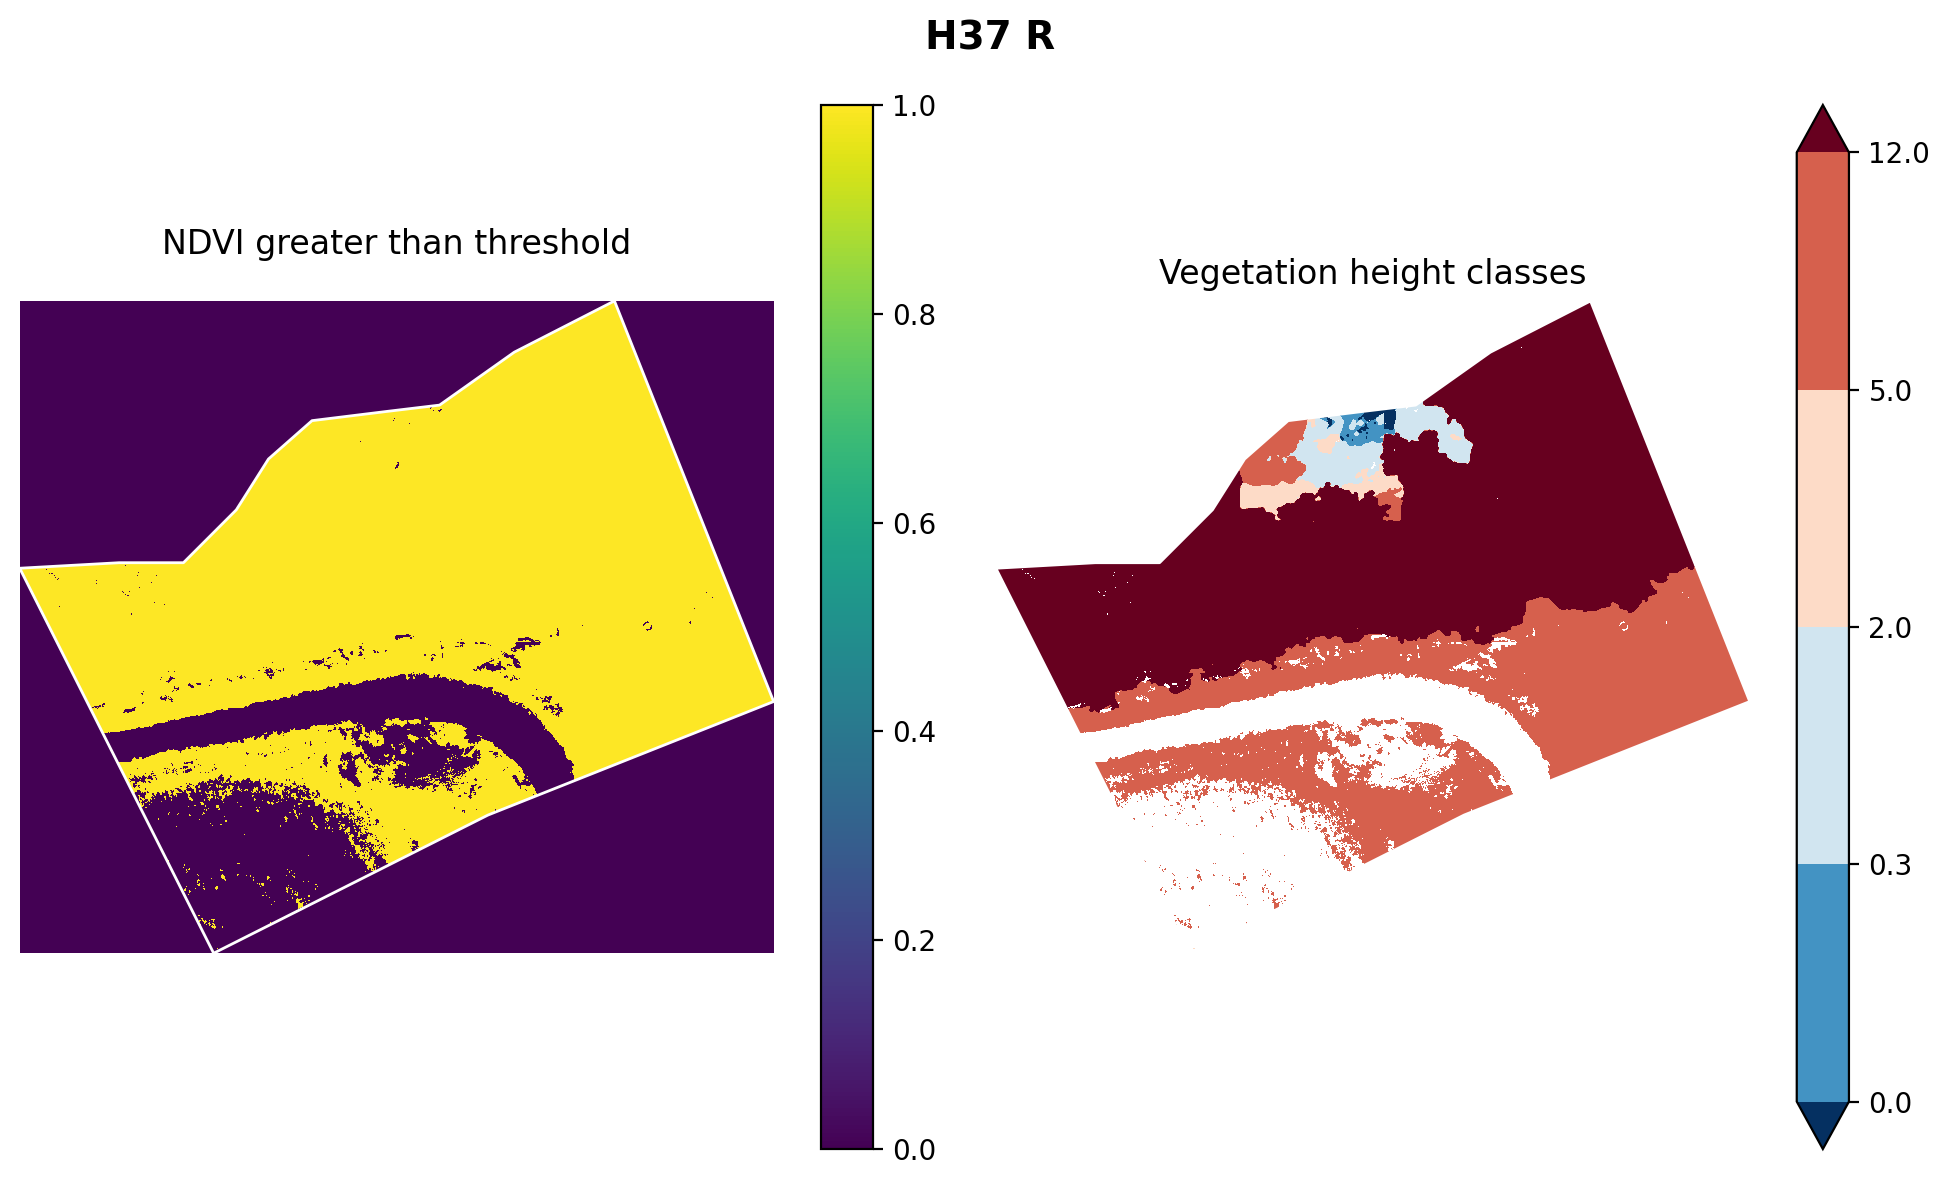

In [8]:
# An area is defined as "vegetated" if NDVI >= ndvi_thresh
ndvi_thresh = 0.2

# Class ranges include the lower limit, but not the upper one
height_class_dict = {
    0: (-1e6, 0),
    1: (0, 0.3),
    2: (0.3, 2),
    3: (2, 5),
    4: (5, 12),
    5: (12, 1e6),
}

# Loop over datasets
veg_dict_rip = {
    "site": [],
    "veg_area_m2": [],
    "class_0_pct": [],
    "class_1_pct": [],
    "class_2_pct": [],
    "class_3_pct": [],
    "class_4_pct": [],
    "class_5_pct": [],
}
for idx, row in df.iterrows():
    base_elev = row["base_line_height"]
    str_id = row["stream_id"]
    site = row["site"]

    # Setup plot
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

    # Get vector data for site
    site_rip_gdf = rip_gdf.query("Stream_id == @str_id").copy()

    # Read NDVI data
    ndvi_tif_path = os.path.join("/home/notebook/shared-seabee-ns9879k", row["ndvi"])
    ndvi_data = rio.open_rasterio(ndvi_tif_path, mask_and_scale=True)

    # Read elevation data that was resampled to match NDVI in previous notebook
    mission_dir = row["ndvi"].split("/")[2]
    search_path = os.path.join(
        "/home/notebook/shared-seabee-ns9879k/niva-tidy/2023",
        mission_dir,
        "rgb_dsm_resampled",
        "*_dsm.tif",
    )
    flist = glob.glob(search_path)
    assert len(flist) == 1
    dem_tif_path = flist[0]
    dem_data = rio.open_rasterio(dem_tif_path, mask_and_scale=True)

    # Subtract baseline elevation to give vegetation height
    dem_data = dem_data - base_elev

    # Reproject if necessary
    assert ndvi_data.rio.crs == dem_data.rio.crs
    assert ndvi_data.shape == dem_data.shape
    site_rip_gdf = site_rip_gdf.to_crs(ndvi_data.rio.crs)

    # Extract pixels within riparian area
    masked_ndvi = ndvi_data.rio.clip(site_rip_gdf.geometry, site_rip_gdf.crs)
    masked_dem = dem_data.rio.clip(site_rip_gdf.geometry, site_rip_gdf.crs)

    # Calculate area with NDVI values >= ndvi_thresh
    transform = masked_ndvi.rio.transform()
    pixel_width, pixel_height = round(transform[0], 5), -round(transform[4], 5)
    assert pixel_width == pixel_height
    veg_pixels = masked_ndvi >= ndvi_thresh
    veg_pixel_count = veg_pixels.sum().item()
    veg_area_m2 = veg_pixel_count * pixel_width * pixel_height
    veg_dict_rip["veg_area_m2"].append(veg_area_m2)
    veg_dict_rip["site"].append(site)

    # Plot NDVI above threshold
    veg_pixels.plot(ax=axes[0])
    site_rip_gdf.plot(ax=axes[0], edgecolor="white", facecolor="none", lw=1)
    axes[0].set_title("NDVI greater than threshold")
    axes[0].axis("off")

    # Extract data for vegetation cells
    veg_data = veg_pixels.values
    elev_data = masked_dem.values
    assert veg_data.shape == elev_data.shape
    elev_data[~veg_data] = np.nan

    # Loop over classes
    for class_id, (lower_limit, upper_limit) in height_class_dict.items():
        mask = (elev_data >= lower_limit) & (elev_data < upper_limit)
        class_count = np.sum(mask)
        class_area_m2 = class_count * pixel_width * pixel_height
        class_area_pct = 100 * class_area_m2 / veg_area_m2
        veg_dict_rip[f"class_{class_id}_pct"].append(class_area_pct)

    # Plot class map
    masked_dem.values = elev_data
    masked_dem.plot(ax=axes[1], levels=[0, 0.3, 2, 5, 12])
    site_rip_gdf.plot(ax=axes[1], edgecolor="white", facecolor="none", lw=1)
    axes[1].set_title("Vegetation height classes")
    axes[1].axis("off")
    fig.suptitle(site, fontsize=14, fontweight="bold")
    plt.tight_layout()

    # Save plot
    png_path = f"../plots/veg_comp_riparian_area/veg_comp_riparian_area_{site.replace(' ', '-').lower()}.png"
    plt.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.close()

# Add to results
veg_df_rip = pd.DataFrame(veg_dict_rip).round(1)
res_dict["veg_comp_riparian_area"] = veg_df_rip

# Show results
display(veg_df_rip)
Image(filename=png_path)

#### 3.4.2. Vegetation polygons only

The areas of interest are the polygons defining just the vegetation.

,site,veg_area_m2,class_0_pct,class_1_pct,class_2_pct,class_3_pct,class_4_pct,class_5_pct
0,H20 L,242.4,0.0,0.1,5.7,6.5,33.6,54.0
1,H20 R,430.1,0.2,2.3,14.4,7.5,53.3,22.4
2,H21 L,1304.7,6.7,5.8,35.8,27.3,8.3,16.0
3,H21 R,1512.8,6.8,1.9,8.6,4.8,25.5,52.3
4,H22 L,265.7,0.0,1.3,55.9,33.0,9.8,0.0
5,H22 R,107.9,0.0,6.7,90.0,3.1,0.3,0.0
6,H23 R,1411.6,0.1,5.0,17.5,8.5,61.7,7.3
7,H24 L,487.0,0.8,4.3,18.1,5.8,18.7,52.3
8,H24 R,108.0,2.4,12.2,80.6,0.3,1.6,2.9
9,H25 L,1011.0,1.8,2.6,18.6,34.5,42.5,0.0


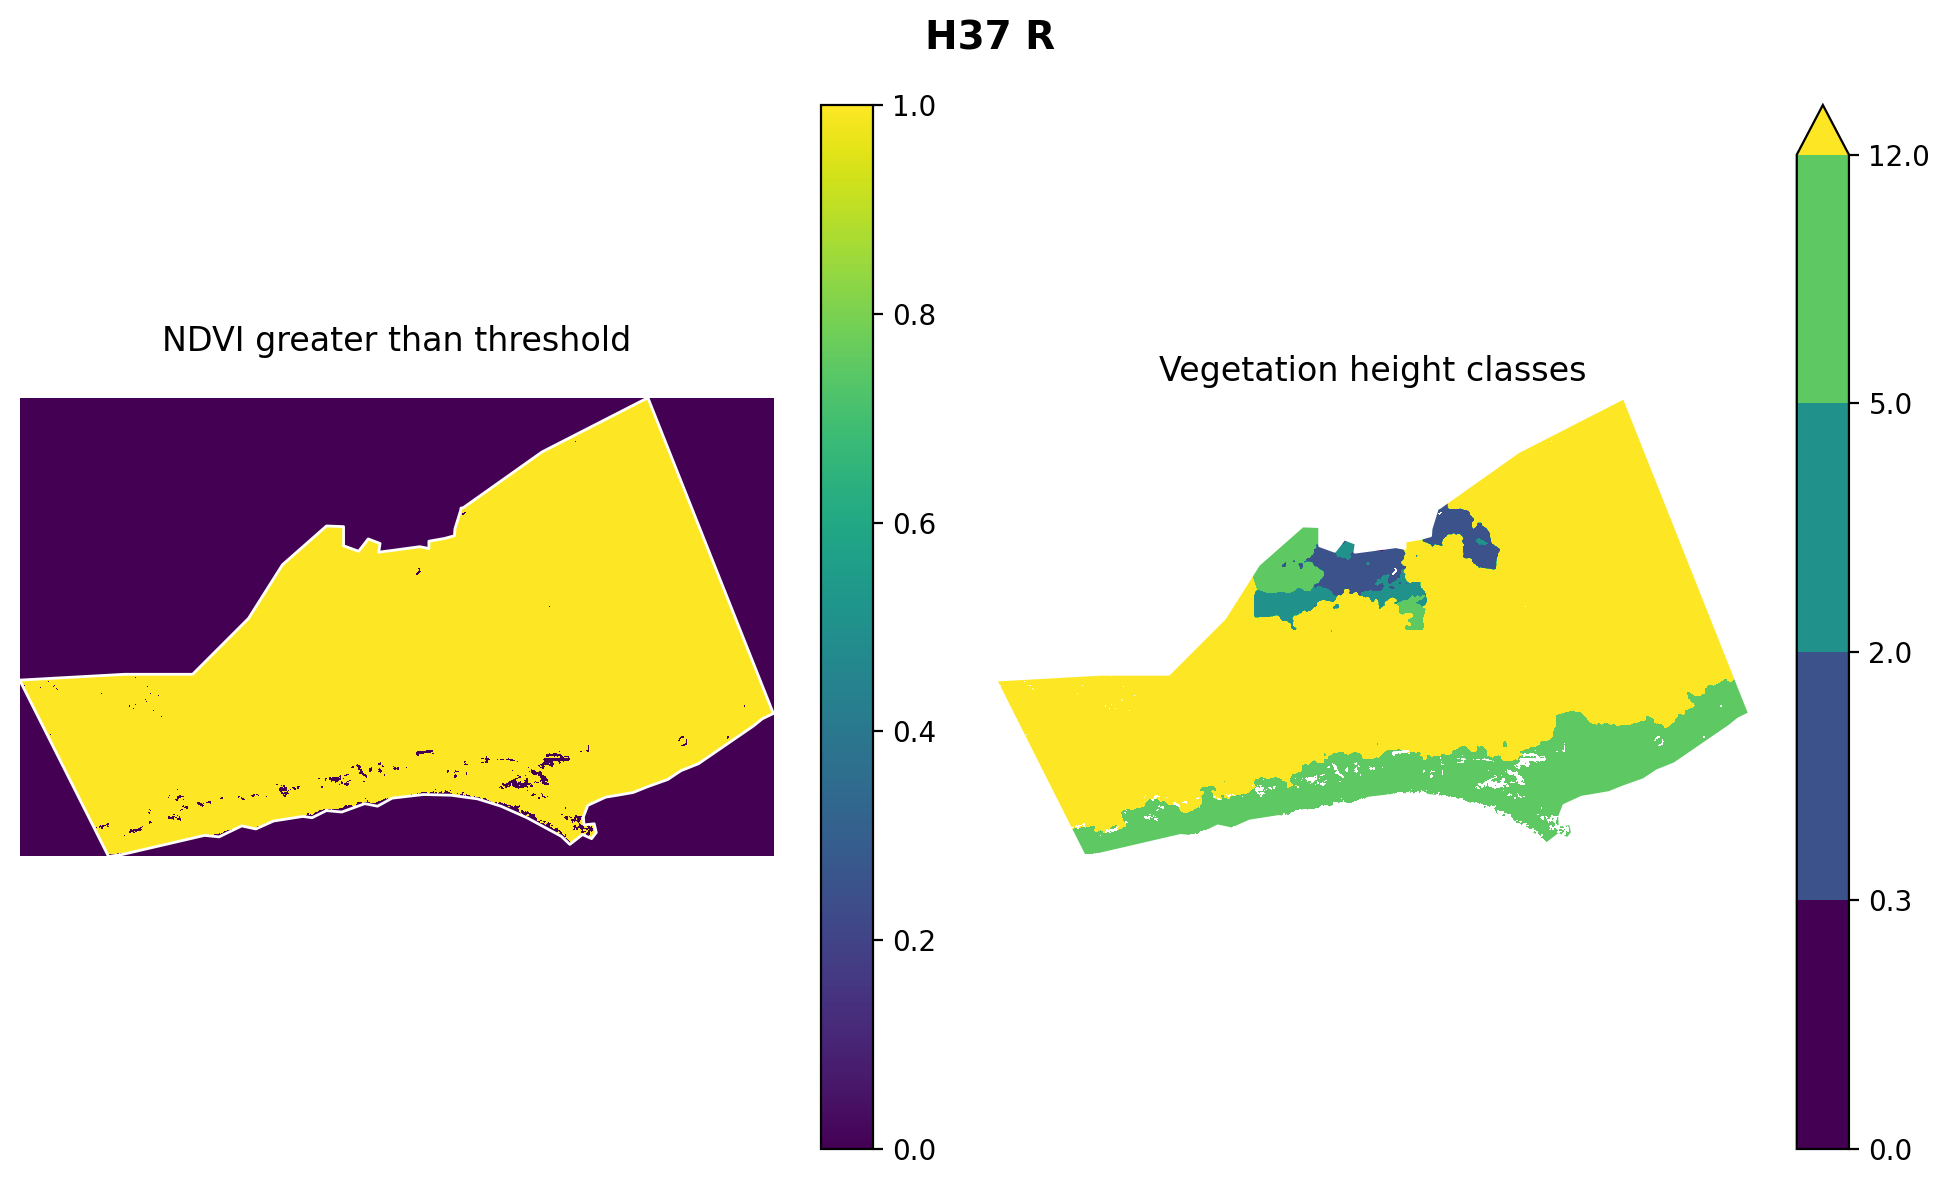

In [9]:
# An area is defined as "vegetated" if NDVI >= ndvi_thresh
ndvi_thresh = 0.2

# Class ranges include the lower limit, but not the upper one
height_class_dict = {
    0: (-1e6, 0),
    1: (0, 0.3),
    2: (0.3, 2),
    3: (2, 5),
    4: (5, 12),
    5: (12, 1e6),
}

# Loop over datasets
veg_dict_veg = {
    "site": [],
    "veg_area_m2": [],
    "class_0_pct": [],
    "class_1_pct": [],
    "class_2_pct": [],
    "class_3_pct": [],
    "class_4_pct": [],
    "class_5_pct": [],
}
for idx, row in df.iterrows():
    base_elev = row["base_line_height"]
    str_id = row["stream_id"]
    site = row["site"]
    site_main = site[:3]

    # Setup plot
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))

    # Get vector data for site
    site_rip_gdf = rip_gdf.query("Stream_id == @str_id").copy()
    site_veg_gdf = veg_gdf.query("Stream_ID == @site_main").copy()

    # Clip vegetation with riparian poly
    site_veg_gdf = gpd.clip(site_veg_gdf, site_rip_gdf, keep_geom_type=True)

    # Read NDVI data
    ndvi_tif_path = os.path.join("/home/notebook/shared-seabee-ns9879k", row["ndvi"])
    ndvi_data = rio.open_rasterio(ndvi_tif_path, mask_and_scale=True)

    # Read elevation data that was resampled to match NDVI in previous notebook
    mission_dir = row["ndvi"].split("/")[2]
    search_path = os.path.join(
        "/home/notebook/shared-seabee-ns9879k/niva-tidy/2023",
        mission_dir,
        "rgb_dsm_resampled",
        "*_dsm.tif",
    )
    flist = glob.glob(search_path)
    assert len(flist) == 1
    dem_tif_path = flist[0]
    dem_data = rio.open_rasterio(dem_tif_path, mask_and_scale=True)

    # Subtract baseline elevation to give vegetation height
    dem_data = dem_data - base_elev

    # Reproject if necessary
    assert ndvi_data.rio.crs == dem_data.rio.crs
    assert ndvi_data.shape == dem_data.shape
    site_veg_gdf = site_veg_gdf.to_crs(ndvi_data.rio.crs)

    # Extract pixels within riparian area
    masked_ndvi = ndvi_data.rio.clip(site_veg_gdf.geometry, site_veg_gdf.crs)
    masked_dem = dem_data.rio.clip(site_veg_gdf.geometry, site_veg_gdf.crs)

    # Calculate area with NDVI values >= ndvi_thresh
    transform = masked_ndvi.rio.transform()
    pixel_width, pixel_height = round(transform[0], 5), -round(transform[4], 5)
    assert pixel_width == pixel_height
    veg_pixels = masked_ndvi >= ndvi_thresh
    veg_pixel_count = veg_pixels.sum().item()
    veg_area_m2 = veg_pixel_count * pixel_width * pixel_height
    veg_dict_veg["veg_area_m2"].append(veg_area_m2)
    veg_dict_veg["site"].append(site)

    # Plot NDVI above threshold
    veg_pixels.plot(ax=axes[0])
    site_veg_gdf.plot(ax=axes[0], edgecolor="white", facecolor="none", lw=1)
    axes[0].set_title("NDVI greater than threshold")
    axes[0].axis("off")

    # Extract data for vegetation cells
    veg_data = veg_pixels.values
    elev_data = masked_dem.values
    assert veg_data.shape == elev_data.shape
    elev_data[~veg_data] = np.nan

    # Loop over classes
    for class_id, (lower_limit, upper_limit) in height_class_dict.items():
        mask = (elev_data >= lower_limit) & (elev_data < upper_limit)
        class_count = np.sum(mask)
        class_area_m2 = class_count * pixel_width * pixel_height
        class_area_pct = 100 * class_area_m2 / veg_area_m2
        veg_dict_veg[f"class_{class_id}_pct"].append(class_area_pct)

    # Plot class map
    masked_dem.values = elev_data
    masked_dem.plot(ax=axes[1], levels=[0, 0.3, 2, 5, 12])
    site_veg_gdf.plot(ax=axes[1], edgecolor="white", facecolor="none", lw=1)
    axes[1].set_title("Vegetation height classes")
    axes[1].axis("off")
    fig.suptitle(site, fontsize=14, fontweight="bold")
    plt.tight_layout()

    # Save plot
    png_path = f"../plots/veg_comp_veg_only/veg_comp_veg_only_{site.replace(' ', '-').lower()}.png"
    plt.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.close()

# Add to results
veg_df_veg = pd.DataFrame(veg_dict_veg).round(1)
res_dict["veg_comp_veg_only"] = veg_df_veg

# Show results
display(veg_df_veg)
Image(filename=png_path)

## 4. Save all results

In [10]:
xl_path = r"../data/summary_results.xlsx"
with pd.ExcelWriter(xl_path) as writer:
    for sheet_name, df in res_dict.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)